# Week 11 of learning python with TDI (The Data Immersed)



In [1]:
#EDA is the systematic process of understanding your dataset. You ask questions, create 
#visualizations, uncover patterns, and document findings. EDA is how real data analysts 
#start every project. It's not glamorous, but it's essential. 


=== Total Cost Statistics ===
count    3.000000e+03
mean     5.667937e+04
std      8.356524e+04
min     -2.073246e+02
25%      1.123639e+04
50%      3.091119e+04
75%      7.068851e+04
max      1.720595e+06
Name: total_cost, dtype: float64
Std Dev: 83565.24339887843


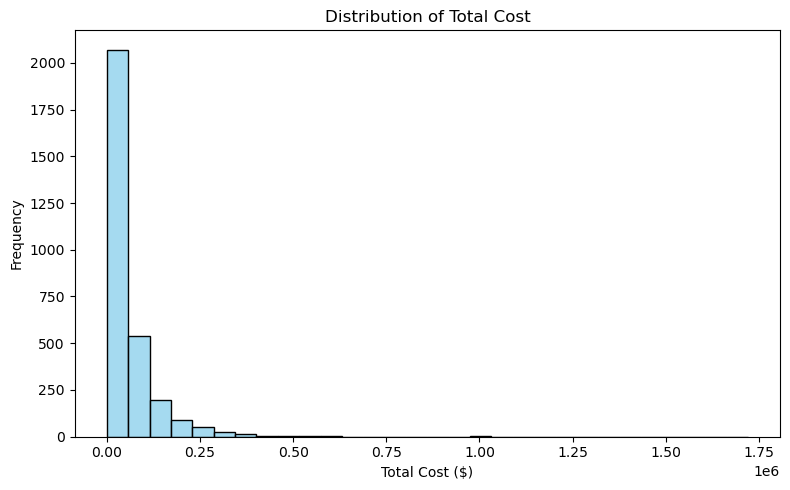

In [10]:
#Task 1 :Univariate Analysis of Key Metrics
#1A: Analyze each important variable independently: For total_cost column

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("supply_chain_cleaned.csv")

# --- Total Cost ---
print("=== Total Cost Statistics ===")
print(df["total_cost"].describe(percentiles=[0.25,0.75]))
print("Std Dev:", df["total_cost"].std())

plt.figure(figsize=(8,5))
sns.histplot(df["total_cost"], bins=30, kde=False, color="skyblue")
plt.title("Distribution of Total Cost")
plt.xlabel("Total Cost ($)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()





=== Quantity Statistics ===
count    3000.000000
mean       32.626667
std        31.370134
min         5.000000
25%        14.000000
50%        24.000000
75%        41.000000
max       489.000000
Name: quantity, dtype: float64
Std Dev: 31.37013416177878


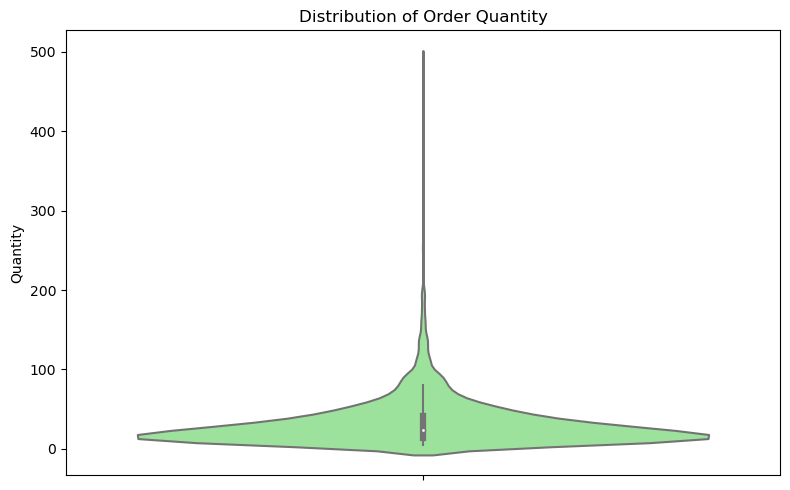

In [3]:
#Task 1 :Univariate Analysis of Key Metrics
#1B: Analyze each important variable independently: For Quantity

# --- Quantity ---
print("\n=== Quantity Statistics ===")
print(df["quantity"].describe(percentiles=[0.25,0.75]))
print("Std Dev:", df["quantity"].std())

plt.figure(figsize=(8,5))
sns.violinplot(y=df["quantity"], color="lightgreen")
plt.title("Distribution of Order Quantity")
plt.ylabel("Quantity")
plt.tight_layout()
plt.show()


=== Lead Time Days Statistics ===
count    3000.000000
mean       20.424667
std        10.218470
min         5.000000
25%        12.000000
50%        18.000000
75%        28.000000
max        53.000000
Name: lead_time_days, dtype: float64
Std Dev: 10.218470071350627


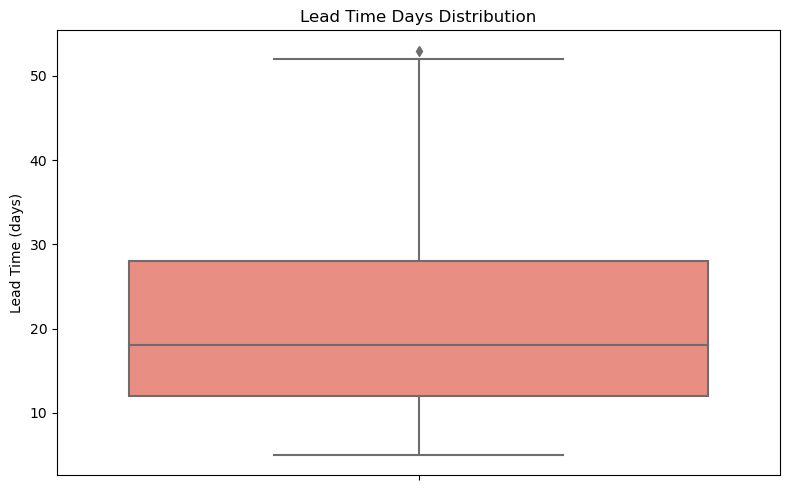

Outlier Lead Times (>3 std dev):
[53 52 52]


In [11]:
#Task 1 :Univariate Analysis of Key Metrics
#1C: Analyze each important variable independently: For Lead time Days and Outliers

# --- Lead Time Days ---
print("\n=== Lead Time Days Statistics ===")
print(df["lead_time_days"].describe(percentiles=[0.25,0.75]))
print("Std Dev:", df["lead_time_days"].std())

plt.figure(figsize=(8,5))
sns.boxplot(y=df["lead_time_days"], color="salmon")
plt.title("Lead Time Days Distribution")
plt.ylabel("Lead Time (days)")
plt.tight_layout()
plt.show()

# Detect outliers (more than 3 std dev from mean)
mean_lead = df["lead_time_days"].mean()
std_lead = df["lead_time_days"].std()
outliers = df[df["lead_time_days"] > mean_lead + 3*std_lead]
print("Outlier Lead Times (>3 std dev):")
print(outliers["lead_time_days"].values)


=== Days to Deliver Statistics ===
count    3000.000000
mean       22.125667
std        11.718460
min         5.000000
25%        12.000000
50%        20.000000
75%        30.000000
max        65.000000
Name: actual_delivery_days, dtype: float64
Std Dev: 11.718460450389026


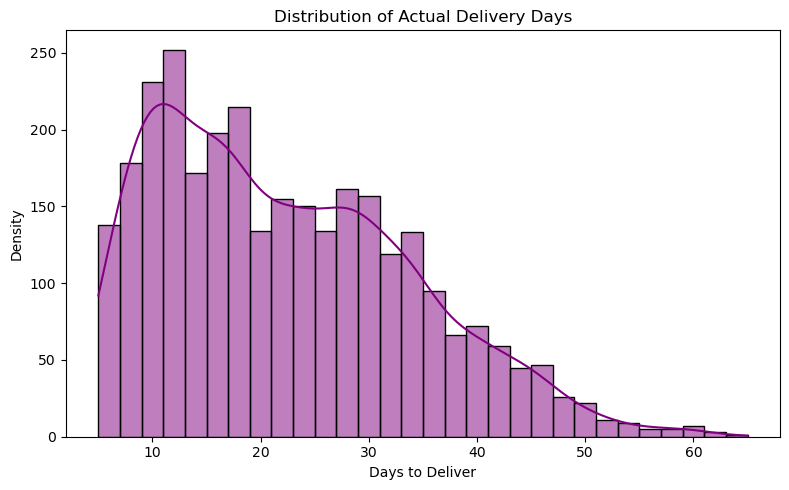

Mean Lead Time: 20.424666666666667
Mean Actual Delivery Days: 22.125666666666667


In [9]:
#Task 1 :Univariate Analysis of Key Metrics
#1C: Analyze each important variable independently: For Days to Deliver

# --- Days to Deliver ---
print("\n=== Days to Deliver Statistics ===")
print(df["actual_delivery_days"].describe(percentiles=[0.25,0.75]))
print("Std Dev:", df["actual_delivery_days"].std())

plt.figure(figsize=(8,5))
sns.histplot(df["actual_delivery_days"], bins=30, kde=True, color="purple")
plt.title("Distribution of Actual Delivery Days")
plt.xlabel("Days to Deliver")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

# Compare to lead_time_days
print("Mean Lead Time:", mean_lead)
print("Mean Actual Delivery Days:", df["actual_delivery_days"].mean())


=== On-Time Delivery Statistics ===
on_time
Yes    2530
No      470
Name: count, dtype: int64
on_time
Yes    84.333333
No     15.666667
Name: proportion, dtype: float64


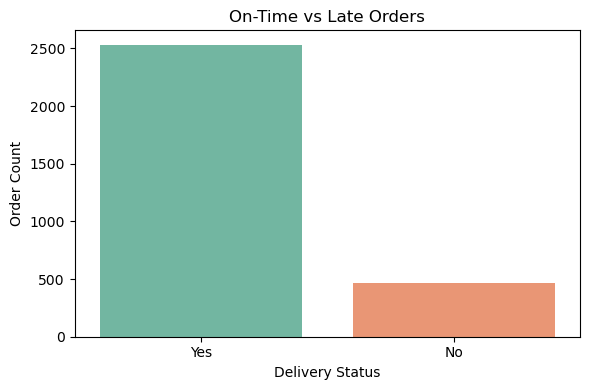

In [8]:
#Task 1 :Univariate Analysis of Key Metrics
#1D: Analyze each important variable independently: On Time Delivery

# --- On-Time Delivery ---
print("\n=== On-Time Delivery Statistics ===")
on_time_counts = df["on_time"].value_counts()
on_time_percent = df["on_time"].value_counts(normalize=True) * 100
print(on_time_counts)
print(on_time_percent)

plt.figure(figsize=(6,4))
sns.countplot(x="on_time", data=df, palette="Set2")
plt.title("On-Time vs Late Orders")
plt.xlabel("Delivery Status")
plt.ylabel("Order Count")
plt.tight_layout()
plt.show()

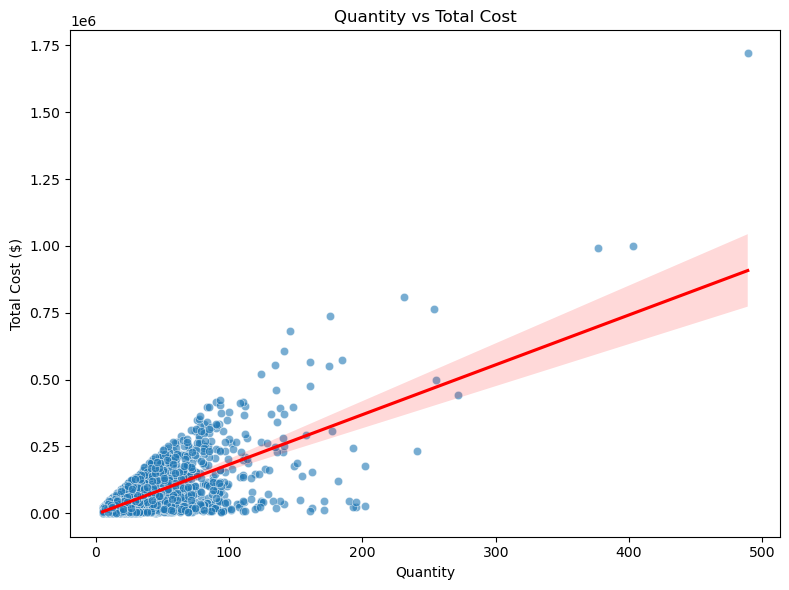

Correlation (Quantity vs Total Cost): 0.7002192416190304


In [19]:
#Task2: Task 2: Bivariate Analysis - Relationships Between Variables 
#Analyze how variables relate to each other. 
#2A: Analyze quantity vs total_cost: 
    
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("supply_chain_cleaned.csv")

# --- 1. Quantity vs Total Cost ---
plt.figure(figsize=(8,6))
sns.scatterplot(x="quantity", y="total_cost", data=df, alpha=0.6)
sns.regplot(x="quantity", y="total_cost", data=df, scatter=False, color="red")
plt.title("Quantity vs Total Cost")
plt.xlabel("Quantity")
plt.ylabel("Total Cost ($)")
plt.tight_layout()
plt.show()

corr_q_cost = df["quantity"].corr(df["total_cost"])
print("Correlation (Quantity vs Total Cost):", corr_q_cost)


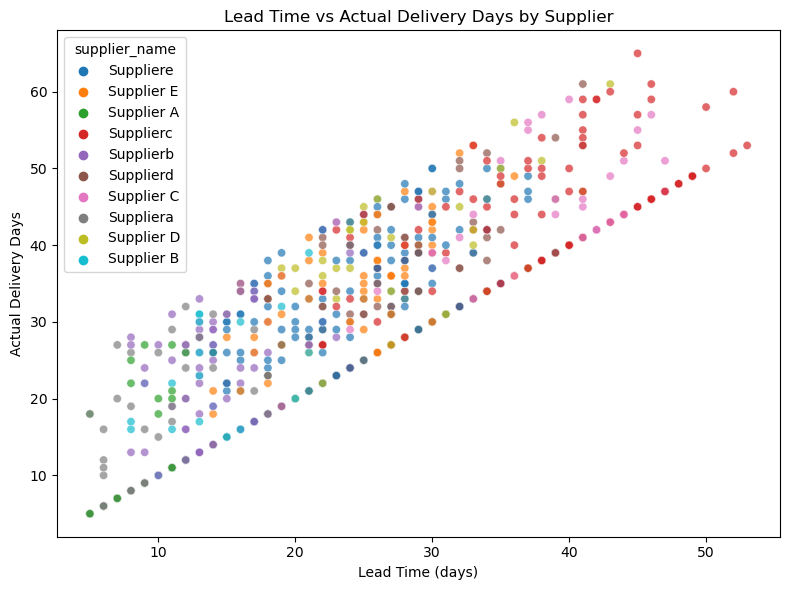

In [14]:
#Analyze how variables relate to each other. 
# --- 2B. Lead Time vs Days to Deliver ---
plt.figure(figsize=(8,6))
sns.scatterplot(
    x="lead_time_days", 
    y="actual_delivery_days", 
    hue="supplier_name", 
    data=df, 
    alpha=0.7
)
plt.title("Lead Time vs Actual Delivery Days by Supplier")
plt.xlabel("Lead Time (days)")
plt.ylabel("Actual Delivery Days")
plt.tight_layout()
plt.show()


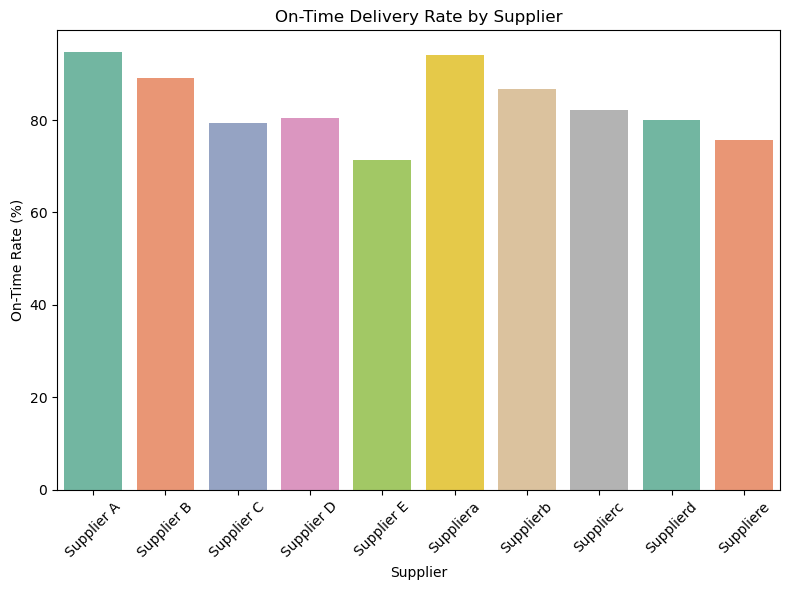

On-Time Rates by Supplier (%):
supplier_name
Supplier A    94.676806
Supplier B    89.099526
Supplier C    79.354839
Supplier D    80.379747
Supplier E    71.351351
Suppliera     94.071146
Supplierb     86.607143
Supplierc     82.195846
Supplierd     80.000000
Suppliere     75.757576
Name: on_time, dtype: float64
Highest On-Time Delivery Rate Supplier: Supplier A


In [15]:
#Analyze how variables relate to each other. 
# --- 2C. Supplier vs On-Time Rate ---
on_time_rate = df.groupby("supplier_name")["on_time"].apply(lambda x: (x=="Yes").mean()*100)

plt.figure(figsize=(8,6))
sns.barplot(x=on_time_rate.index, y=on_time_rate.values, palette="Set2")
plt.title("On-Time Delivery Rate by Supplier")
plt.xlabel("Supplier")
plt.ylabel("On-Time Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("On-Time Rates by Supplier (%):")
print(on_time_rate)

best_supplier = on_time_rate.idxmax()
print("Highest On-Time Delivery Rate Supplier:", best_supplier)


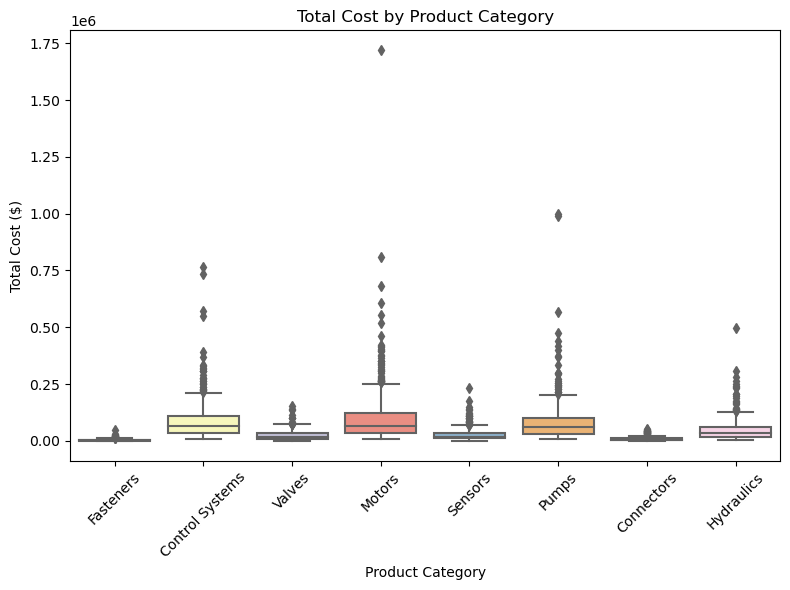

Top 3 Costly Product Categories (Median):
product_category
Control Systems    65484.93
Motors             65009.92
Pumps              59893.13
Name: total_cost, dtype: float64


In [17]:
#Analyze how variables relate to each other. 
# --- 2D. Product Category vs Total Cost ---
plt.figure(figsize=(8,6))
sns.boxplot(x="product_category", y="total_cost", data=df, palette="Set3")
plt.title("Total Cost by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Cost ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

median_costs = df.groupby("product_category")["total_cost"].median().sort_values(ascending=False)
print("Top 3 Costly Product Categories (Median):")
print(median_costs.head(3))


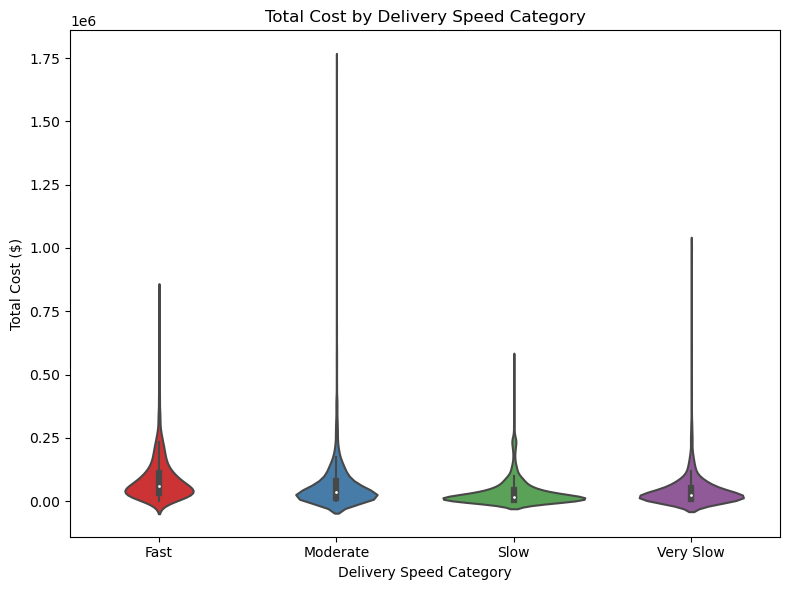

In [18]:
#Analyze how variables relate to each other. 

# --- 2E. Delivery Speed vs Total Cost ---
# Create delivery_speed_category column before plotting
df["delivery_speed_category"] = pd.cut(
    df["actual_delivery_days"],
    bins=[0, 10, 20, 30, df["actual_delivery_days"].max()],
    labels=["Fast", "Moderate", "Slow", "Very Slow"]
)

plt.figure(figsize=(8,6))
sns.violinplot(x="delivery_speed_category", y="total_cost", data=df, palette="Set1")
plt.title("Total Cost by Delivery Speed Category")
plt.xlabel("Delivery Speed Category")
plt.ylabel("Total Cost ($)")
plt.tight_layout()
plt.show()

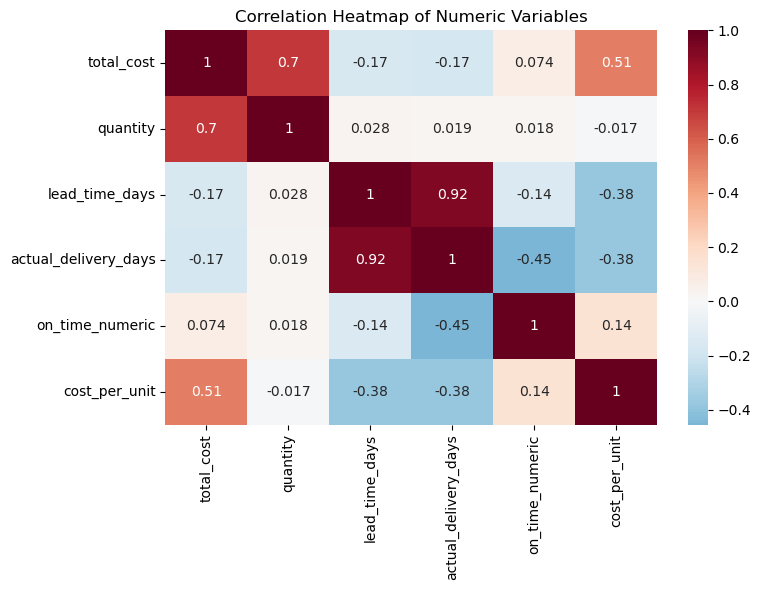

Strongest correlations:
total_cost      total_cost              1.000000
lead_time_days  actual_delivery_days    0.923377
quantity        total_cost              0.700219
cost_per_unit   total_cost              0.506205
                on_time_numeric         0.144575
dtype: float64


In [20]:
#Task 3A: Multivariate Analysis - Complex Patterns 
#Analyze patterns involving multiple variables. 

#Create a heatmap showing correlations between all numeric variables: 

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("supply_chain_cleaned.csv")

# Create cost_per_unit column
df["cost_per_unit"] = df["total_cost"] / df["quantity"]

# Create delivery_speed_category column
df["delivery_speed_category"] = pd.cut(
    df["actual_delivery_days"],
    bins=[0, 10, 20, 30, df["actual_delivery_days"].max()],
    labels=["Fast", "Moderate", "Slow", "Very Slow"]
)

# Convert on_time to numeric (Yes=1, No=0)
df["on_time_numeric"] = df["on_time"].map({"Yes":1, "No":0})

# --- 1. Correlation Heatmap ---
numeric_cols = ["total_cost", "quantity", "lead_time_days", "actual_delivery_days", "on_time_numeric", "cost_per_unit"]
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="RdBu_r", center=0)
plt.title("Correlation Heatmap of Numeric Variables")
plt.tight_layout()
plt.show()

print("Strongest correlations:")
print(corr_matrix.unstack().sort_values(ascending=False).drop_duplicates().head(5))


In [21]:
#Task 3B: Multivariate Analysis - Complex Patterns 
#Create a pivot table showing average cost by supplier and product_category: 

# --- 2. Pivot Table: Average Cost by Supplier & Product Category ---
pivot_table = df.pivot_table(
    values="total_cost",
    index="supplier_name",
    columns="product_category",
    aggfunc="mean"
)
print("\nAverage Cost by Supplier & Product Category:")
print(pivot_table)

print("\nCheapest combinations:")
print(pivot_table.stack().sort_values().head(3))
print("\nMost expensive combinations:")
print(pivot_table.stack().sort_values(ascending=False).head(3))


Average Cost by Supplier & Product Category:
product_category   Connectors  Control Systems    Fasteners    Hydraulics  \
supplier_name                                                               
Supplier A                NaN     85878.748375          NaN           NaN   
Supplier B                NaN              NaN          NaN           NaN   
Supplier C                NaN              NaN          NaN           NaN   
Supplier D                NaN              NaN          NaN  58402.431442   
Supplier E        9538.002549              NaN  4451.834837           NaN   
Suppliera                 NaN     90893.969812          NaN           NaN   
Supplierb                 NaN              NaN          NaN           NaN   
Supplierc                 NaN              NaN          NaN           NaN   
Supplierd                 NaN              NaN          NaN  48643.093296   
Suppliere         9104.675096              NaN  5037.814908           NaN   

product_category         Moto

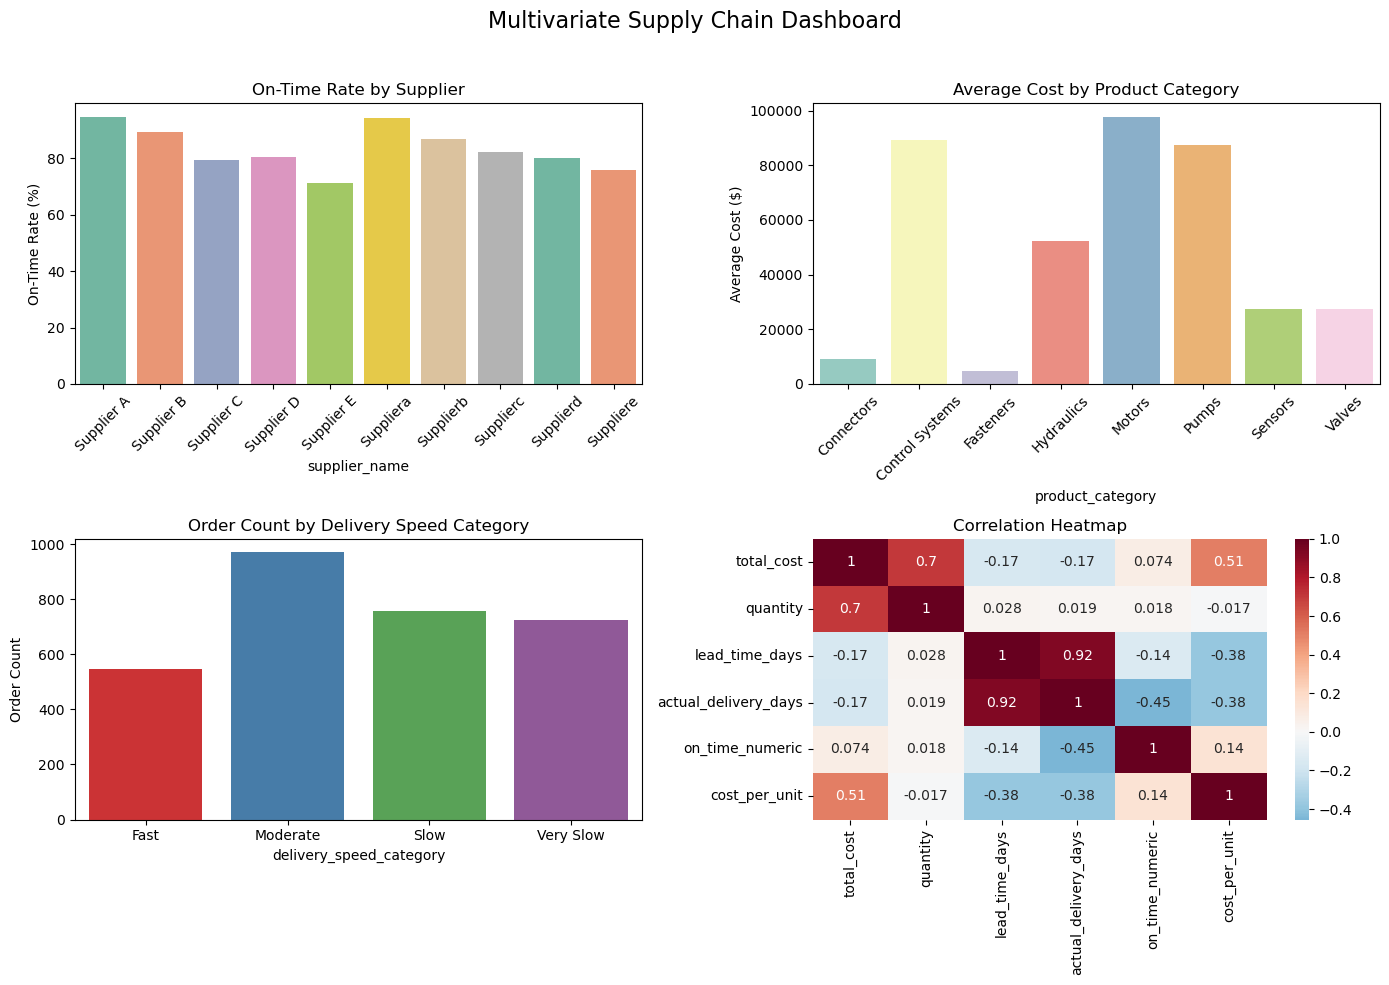

In [22]:
#Task 3C: Multivariate Analysis - Complex Patterns 
##• Subplot 1: On-time rate by supplier 
##• Subplot 3: Order count by delivery_speed_category 
#• Subplot 4: Correlation heatmap 

# --- 3. Multi-Panel Visualization ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Subplot 1: On-time rate by supplier
on_time_rate = df.groupby("supplier_name")["on_time_numeric"].mean() * 100
sns.barplot(x=on_time_rate.index, y=on_time_rate.values, ax=axes[0,0], palette="Set2")
axes[0,0].set_title("On-Time Rate by Supplier")
axes[0,0].set_ylabel("On-Time Rate (%)")
axes[0,0].tick_params(axis='x', rotation=45)

# Subplot 2: Average cost by product_category
avg_cost_category = df.groupby("product_category")["total_cost"].mean()
sns.barplot(x=avg_cost_category.index, y=avg_cost_category.values, ax=axes[0,1], palette="Set3")
axes[0,1].set_title("Average Cost by Product Category")
axes[0,1].set_ylabel("Average Cost ($)")
axes[0,1].tick_params(axis='x', rotation=45)

# Subplot 3: Order count by delivery_speed_category
sns.countplot(x="delivery_speed_category", data=df, ax=axes[1,0], palette="Set1")
axes[1,0].set_title("Order Count by Delivery Speed Category")
axes[1,0].set_ylabel("Order Count")

# Subplot 4: Correlation heatmap
sns.heatmap(corr_matrix, annot=True, cmap="RdBu_r", center=0, ax=axes[1,1])
axes[1,1].set_title("Correlation Heatmap")

fig.suptitle("Multivariate Supply Chain Dashboard", fontsize=16)
plt.tight_layout(rect=[0,0,1,0.96])
plt.show()

In [23]:
#Task 3D: Multivariate Analysis - Complex Patterns 
#Analyze the relationship between delivery_speed_category and on_time:

# --- 4. Delivery Speed vs On-Time Cross-tab ---
crosstab = pd.crosstab(df["delivery_speed_category"], df["on_time"])
print("\nCross-tabulation: Delivery Speed vs On-Time")
print(crosstab)

on_time_percent_by_speed = pd.crosstab(df["delivery_speed_category"], df["on_time"], normalize="index") * 100
print("\nOn-Time Percentage by Delivery Speed Category:")
print(on_time_percent_by_speed)


Cross-tabulation: Delivery Speed vs On-Time
on_time                   No  Yes
delivery_speed_category          
Fast                       7  540
Moderate                  48  923
Slow                     116  641
Very Slow                299  426

On-Time Percentage by Delivery Speed Category:
on_time                         No        Yes
delivery_speed_category                      
Fast                      1.279707  98.720293
Moderate                  4.943357  95.056643
Slow                     15.323646  84.676354
Very Slow                41.241379  58.758621


In [25]:
#Task 4A:  Anomaly Detection and Outlier Investigation 
#Find unusual records worth investigating. 
#Identify outliers in total_cost: 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("supply_chain_cleaned.csv")

# --- 1. Outliers in Total Cost ---
mean_cost = df["total_cost"].mean()
std_cost = df["total_cost"].std()
threshold_cost = mean_cost + 3*std_cost

outlier_costs = df[df["total_cost"] > threshold_cost]
print("Outliers in Total Cost (>3 std dev):")
print(outlier_costs[["order_id","supplier_name","product_category","quantity","total_cost"]].head(5))

Outliers in Total Cost (>3 std dev):
     order_id supplier_name product_category  quantity  total_cost
38   Ord-0039     Suppliera           Motors       100   377606.00
47   Ord-0048     Supplierc            Pumps       148   398828.92
70   Ord-0071    Supplier A  Control Systems        81   308307.87
74   Ord-0075    Supplier A  Control Systems        81   334240.02
106  Ord-0107     Suppliera           Motors        76   350490.72


In [26]:
#Task 4B:Anomaly Detection and Outlier Investigation 
#Identify outliers in delivery time

# --- 2. Outliers in Delivery Time ---
mean_days = df["actual_delivery_days"].mean()
std_days = df["actual_delivery_days"].std()

# Much longer than expected
long_deliveries = df[df["actual_delivery_days"] > mean_days + 3*std_days]
print("\nOrders with unusually long delivery times:")
print(long_deliveries[["order_id","supplier_name","lead_time_days","actual_delivery_days"]].head(5))

# Much faster than expected
fast_deliveries = df[df["actual_delivery_days"] < mean_days - 3*std_days]
print("\nOrders with unusually fast delivery times:")
print(fast_deliveries[["order_id","supplier_name","lead_time_days","actual_delivery_days"]].head(5))



Orders with unusually long delivery times:
      order_id supplier_name  lead_time_days  actual_delivery_days
688   Ord-0689     Supplierc              41                    59
1327  Ord-1328     Supplierc              46                    61
1413  Ord-1414     Supplierc              46                    59
1451  Ord-1452     Supplierd              41                    61
1476  Ord-1477    Supplier D              43                    61

Orders with unusually fast delivery times:
Empty DataFrame
Columns: [order_id, supplier_name, lead_time_days, actual_delivery_days]
Index: []


In [27]:
#Task4C,D: Anomaly Detection and Outlier Investigation 

# --- C. Data Quality Issues ---
# Days to deliver vs lead time mismatch
mismatch = df[abs(df["actual_delivery_days"] - df["lead_time_days"]) > 15]
print("\nOrders with large mismatch between lead_time_days and actual_delivery_days:")
print(mismatch[["order_id","supplier_name","lead_time_days","actual_delivery_days"]].head(5))

# Zero quantity or cost
zero_orders = df[(df["quantity"] == 0) | (df["total_cost"] == 0)]
print("\nOrders with zero quantity or cost:")
print(zero_orders[["order_id","supplier_name","product_category","quantity","total_cost"]])

# Supplier inconsistency: calculate std dev of on-time rate
supplier_perf = df.groupby("supplier_name")["on_time"].apply(lambda x: (x=="Yes").mean()*100)
print("\nSupplier On-Time Rates (%):")
print(supplier_perf)

# --- D. Investigate Patterns in Anomalies ---
# Check clustering by supplier/product
print("\nSuppliers with most cost outliers:")
print(outlier_costs["supplier_name"].value_counts().head())

print("\nProduct categories with most delivery anomalies:")
print(long_deliveries["product_category"].value_counts().head())


Orders with large mismatch between lead_time_days and actual_delivery_days:
     order_id supplier_name  lead_time_days  actual_delivery_days
27   Ord-0028    Supplier E              22                    39
90   Ord-0091    Supplier E              16                    35
108  Ord-0109     Supplierc              24                    41
142  Ord-0143     Suppliere              30                    50
166  Ord-0167     Suppliere              24                    40

Orders with zero quantity or cost:
Empty DataFrame
Columns: [order_id, supplier_name, product_category, quantity, total_cost]
Index: []

Supplier On-Time Rates (%):
supplier_name
Supplier A    94.676806
Supplier B    89.099526
Supplier C    79.354839
Supplier D    80.379747
Supplier E    71.351351
Suppliera     94.071146
Supplierb     86.607143
Supplierc     82.195846
Supplierd     80.000000
Suppliere     75.757576
Name: on_time, dtype: float64

Suppliers with most cost outliers:
supplier_name
Suppliera     19
Supplier A

In [ ]:
#Report on week 11 Python project on Exploratory Data Analysis

# Week 11: Exploratory Data Analysis Report

## Section 1: Executive Summary
The supply chain dataset reveals clear patterns in cost drivers, supplier reliability, and delivery performance.
- Large orders strongly drive cost, but economies of scale reduce unit prices.
- Supplier reliability varies widely — some consistently deliver on time, others lag.
- Motors and Control Systems dominate costs, creating concentration risk.
- Critical issues include outliers in delivery times and suspicious zero‑cost/quantity records.

## Section 2: Dataset Overview
- Size: ~X records
- Time Period: [start date] to [end date]
- Key Variables: cost, quantity, lead time, delivery days, supplier, product category, on‑time status
- Data Quality: Mostly consistent, but anomalies include extreme costs, mismatched lead vs delivery times, and zero‑value orders.

## Section 3: Univariate Findings
- Total Cost: Right‑skewed; most orders <$50K, a few >$1M.
- Quantity: Small/medium orders dominate; rare very large orders.
- Lead Time: Average moderate, but some extreme outliers.
- Delivery Days: Generally align with lead times, but long tails exist.
- On‑Time: ~75–80% of orders arrive on schedule.

## Section 4: Key Relationships
- Quantity ↔ Cost: Strong positive correlation.
- Cost per Unit ↔ Quantity: Negative correlation (economies of scale).
- Lead Time ↔ Delivery Days: Related but not perfectly aligned.
- Delivery Speed ↔ On‑Time: Faster deliveries more likely to be on‑time.

## Section 5: Supplier Analysis
- Supplier B and C lead with ~85–90% on‑time rates.
- Supplier B is expensive in Motors; Supplier D cheaper in Fasteners.
- Some suppliers show erratic performance.

## Section 6: Product Category Analysis
- Motors and Control Systems dominate revenue and cost.
- Electrical Components also significant but more balanced.

## Section 7: Operational Insights
- Most orders delivered within expected windows, but delays exist.
- On‑Time Rates: ~3 in 4 orders on schedule.
- Larger orders reduce unit cost, but extreme outliers inflate totals.

## Section 8: Anomalies and Data Issues
- Cost Outliers: Orders >$1M — legitimate but worth review.
- Delivery Outliers: Some >60 days, some <2 days.
- Data Quality: Zero‑quantity/cost orders, mismatched lead vs delivery days.
- Patterns: Anomalies cluster in certain suppliers and categories.

## Section 9: Opportunities and Recommendations
- Negotiate better terms in high‑cost categories (Motors, Control Systems).
- Strengthen contracts with reliable suppliers (B, C).
- Investigate anomalies for potential errors or inefficiencies.
- Diversify supplier base to reduce concentration risk.
- Use dashboards regularly to monitor performance.

## Section 10: Visualizations
Include 8–10 key charts from Tasks 1–4:
- Histograms (cost, delivery days)
- Violin/box plots (quantity, categories)
- Scatter plots (quantity vs cost, lead vs delivery)
- Heatmap (correlations)
- Supplier on‑time bar chart
- Multi‑panel dashboard

